# This notebook performs fault slip analysis (FSA) based on principal stresses from CMG geomechanical simulations. The following data are needed:
- Grid cell coordinates and fault ID extracted from Petrel exported files.
- Principal stresses (STRESMXP, STRESMNP, STRESINT) extracted from CMG simulation results (sr3/gmch.sr3 -> rwo -> numpy).

# Step 1: Peform fault slip analysis

Calculate the following  
1. fault slip indicator: numpy array shape (n_is,n_js,n_ks,n_times) for each case
2. the ratio of shear stress to effective normal stress
3. total number of failed cells: numpy array shape (n_cases,n_faults,n_times)

In [ ]:
import numpy as np
import pandas as pd
from pathlib import Path
from fault_slip_analysis import FSA_stress_based
from tqdm import tqdm
import sys

# add src to path
repo_root = Path.cwd().parent
sys.path.append(str(repo_root / "src"))

################## User Inputs ############################## 
name_prefix = 'test_260703' # file name prefix
n_cases = 2 # number of simulation cases
n_faults = 2 # number of faults
n_times = 2 # number of simulation time steps
fault_cohesion = 1 # fault cohesion in kPa
# paths to input data
fault_strike_dip_csv_path = repo_root/'data'/'Vienna_geothermal'/'raw'/'fault_strike_dip.csv' # path to the fault strike and dip CSV file
coor_fault_npy_path = repo_root/'data'/'Vienna_geothermal'/'coor_fault'/'JD_geothermal_coor&fault_reservoir.npy' # path to the grid coordinates and fault ID numpy file
parameters_csv_path = repo_root/'data'/'Vienna_geothermal'/'params_responses'/f'{name_prefix}_CMG_parameters.csv' # path to the parameters CSV file
principal_stresses_folder = repo_root/'results'/'Vienna_geothermal'/'principal_stresses' # path to the folder containing the principal stress numpy files
# paths to output folder
fault_slip_analysis_folder = repo_root/'results'/'Vienna_geothermal'/'fault_slip_analysis'
################## End of User Inputs #######################

# load data
fault_info = pd.read_csv(fault_strike_dip_csv_path)
coor_fault = np.load(coor_fault_npy_path)
parameters = pd.read_csv(parameters_csv_path)

# create save folders
stress_ratio_folder = fault_slip_analysis_folder/f'{name_prefix}_stress_ratio' # path to the folder to save stress ratio numpy files
stress_ratio_folder.mkdir(parents=True, exist_ok=True)
FSI_folder = fault_slip_analysis_folder/f'{name_prefix}_FSI' # path to the folder to save fault slip indicator numpy files
FSI_folder.mkdir(parents=True, exist_ok=True)

# initialize an array to hold mean shear stress for all cases, faults and time steps
mean_tau = np.full((n_cases,n_faults,n_times), np.nan) # array shape (n_cases,n_faults,n_times)
# initialize an array to hold stress ratio for each case
stress_ratio_by_fault = np.full((107,117,5,6), np.nan) # array shape (n_is,n_js,n_ks,n_times)
# initialize an array to hold mean stress ratio for all cases, faults and time steps
mean_stress_ratio = np.full((n_cases,n_faults,n_times), np.nan) # array shape (n_cases,n_faults,n_times)
# initialize an array to hold fault slip indicator for each case
FSI_by_fault = np.full((107,117,5,6), np.nan) # array shape (n_is,n_js,n_ks,n_times)
# initialize an array to hold total number of failed cells for all cases, faults and time steps
total_failed_cells = np.full((n_cases,n_faults,n_times), np.nan) # array shape (n_cases,n_faults,n_times)

# run analysis
# for case_num in tqdm(range(15,16), desc='Running stress-based fault slip analysis'):
for case_num in tqdm(range(1,n_cases+1), desc='Running stress-based fault slip analysis'):
    # load principal stress arrays
    SH = np.load(principal_stresses_folder/f"{name_prefix}_gmc"/f'case{case_num}_STRESMXP.npy')
    Sh = np.load(principal_stresses_folder/f"{name_prefix}_gmc"/f'case{case_num}_STRESMNP.npy')
    Sv = np.load(principal_stresses_folder/f"{name_prefix}_gmc"/f'case{case_num}_STRESINT.npy')
    # extract the azimuth of the maximum horizontal stress from the parameter dataframe
    SH_azi = parameters.loc[parameters["case_name"] == f'case{case_num}','SH_azi_deg'].iloc[0]

    for fault_id in range(n_faults):
        # run fault slip analysis
        row = fault_info.loc[fault_info['fault_id'] == fault_id].iloc[0]
        sigma, tau, fault_slip_indicator = FSA_stress_based(
            SH = SH,
            Sh = Sh,
            Sv = Sv,
            SH_azi = SH_azi,
            fault_strike = row['fault_strike_deg'],
            fault_dip = row['dip_angle_deg'],
            fault_cohesion = fault_cohesion,
            friction_coefficient = 0.6
            )
        
        # mask a fault based on its id
        fault_id_mask = (coor_fault[:,:,:,3] == fault_id)

        # calculate the mean shear stress for all cases, faults and time steps (note to covert kPa to MPa)
        mean_tau[case_num-1,fault_id,:] = np.nanmean(tau[fault_id_mask]/1000,axis=0) # array shape (n_cases,n_faults,n_times)

        # calculate stress ratio for each fault
        ratio = (tau - fault_cohesion) / sigma
        stress_ratio_by_fault[fault_id_mask] = ratio[fault_id_mask]
        # calculate the mean stress ratio for all cases, faults and time steps
        mean_stress_ratio[case_num-1,fault_id,:] = np.nanmean(stress_ratio_by_fault[fault_id_mask],axis=0) # array shape (n_cases,n_faults,n_times)

        # extract fault slip indicator for each fault 
        FSI_by_fault[fault_id_mask] = fault_slip_indicator[fault_id_mask] # array shape (n_is,n_js,n_ks,n_times)
        
        # calculate the total number of failed cells for all cases, faults and time steps
        total_failed_cells[case_num-1,fault_id,:] = np.nansum(FSI_by_fault[fault_id_mask],axis=0) # array shape (n_cases,n_faults,n_times)

    # save stress ratio for each case
    np.save(stress_ratio_folder/f'case{case_num}_stress_ratio.npy', stress_ratio_by_fault)
    # save fault slip indicator for each case
    np.save(FSI_folder/f'case{case_num}_FSI.npy', FSI_by_fault)

# save the mean shear stress
np.save(fault_slip_analysis_folder/f'{name_prefix}_mean_tau.npy',mean_tau)
# save the mean stress ratio
np.save(fault_slip_analysis_folder/f'{name_prefix}_mean_stress_ratio.npy',mean_stress_ratio)
# save the total number of failed cells
np.save(fault_slip_analysis_folder/f'{name_prefix}_total_failed_cells.npy',total_failed_cells)

print("\nFinished analyzing all cases.")

Running stress-based fault slip analysis: 100%|██████████| 1/1 [00:04<00:00,  4.63s/it]


Finished analyzing all cases.


In [146]:
name_prefix = '250922'
# arr = np.load('data/250919_FSA/case10_FSA.npy')
# arr = np.load('data/250922_mean_stress_ratio.npy')
# arr = np.load('data/250922_mean_tau.npy')
arr = np.load(f'data/{name_prefix}_total_failed_cells.npy')
print(arr.shape)
print(np.nonzero(arr[:,0,2]))
# print(arr[:,0,2])
parameters = pd.read_csv(base_path/'data'/'params_responses'/f'{name_prefix}_CMG_parameters.csv')
print(parameters['SH_MPa/km'].iloc[np.nonzero(arr[:,0,2])]*(-1))
print(parameters['SH_azi_deg'].iloc[np.nonzero(arr[:,0,2])])

(90, 12, 6)
(array([53, 68]),)
53    19.16
68    17.89
Name: SH_MPa/km, dtype: float64
53    319.26
68    317.60
Name: SH_azi_deg, dtype: float64


In [145]:
name_prefix = '251017'
arr = np.load(f'data/{name_prefix}_total_failed_cells.npy')
print(arr.shape)
print(np.nonzero(arr[:,0,2]))
# arr[:,0,:]
parameters = pd.read_csv(base_path/'data'/'params_responses'/f'{name_prefix}_CMG_parameters.csv')
print(parameters['SH_MPa/km'].iloc[np.nonzero(arr[:,0,2])]*(-1))
print(parameters['SH_azi_deg'].iloc[np.nonzero(arr[:,0,2])])

(90, 12, 6)
(array([25, 53]),)
25    18.9643
53    18.7658
Name: SH_MPa/km, dtype: float64
25    319.7118
53    319.6593
Name: SH_azi_deg, dtype: float64


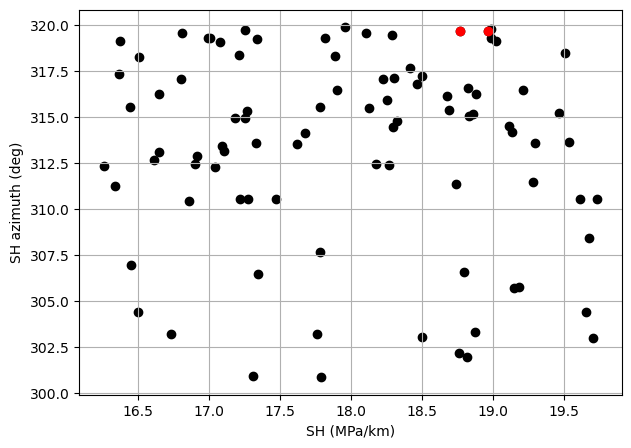

In [140]:
import matplotlib.pyplot as plt

parameters = pd.read_csv(base_path/'data'/'params_responses'/f'{name_prefix}_CMG_parameters.csv')
# plt.figure(1) creates a new, separate window.
plt.figure(1, figsize=(7, 5))
plt.scatter(parameters['SH_MPa/km']*(-1), parameters['SH_azi_deg'],color='black')
plt.scatter(parameters['SH_MPa/km'].iloc[np.nonzero(arr[:,0,2])]*(-1), parameters['SH_azi_deg'].iloc[np.nonzero(arr[:,0,2])],color='red')
# plt.scatter(high_ratio['Vert_Base_Are'], high_ratio['SH_azi_deg'],color='red',label='high stress ratio')
plt.xlabel('SH (MPa/km)')
plt.ylabel('SH azimuth (deg)')
plt.grid(True)
# plt.legend(loc='lower right')

In [147]:
name_prefix = '251020'
arr = np.load(f'data/{name_prefix}_total_failed_cells.npy')
print(arr.shape)
print(np.nonzero(arr[:,0,2]))
print(arr[:,0,2])
parameters = pd.read_csv(base_path/'data'/'params_responses'/f'{name_prefix}_CMG_parameters.csv')
print(parameters['SH_MPa/km'].iloc[np.nonzero(arr[:,0,2])]*(-1))
print(parameters['SH_azi_deg'].iloc[np.nonzero(arr[:,0,2])])

(90, 12, 6)
(array([ 5,  6, 17, 25, 27, 30, 40, 45, 53, 54, 68, 71, 88]),)
[  0.   0.   0.   0.   0. 589. 260.   0.   0.   0.   0.   0.   0.   0.
   0.   0.   0.   3.   0.   0.   0.   0.   0.   0.   0. 596.   0.  38.
   0.   0.  68.   0.   0.   0.   0.   0.   0.   0.   0.   0.   3.   0.
   0.   0.   0. 589.   0.   0.   0.   0.   0.   0.   0. 223. 459.   0.
   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0. 589.   0.
   0.   1.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
   0.   0.   0.   0. 278.   0.]
5     19.1757
6     19.2084
17    18.2178
25    19.2628
27    18.1369
30    19.6295
40    17.5762
45    18.8390
53    19.1352
54    19.4777
68    18.7553
71    19.2781
88    18.5726
Name: SH_MPa/km, dtype: float64
5     319.3134
6     319.2540
17    319.8449
25    319.9424
27    319.6814
30    318.7329
40    319.9199
45    319.4259
53    319.9319
54    318.7156
68    318.4956
71    319.9594
88    319.6633
Name: SH_azi_deg, dtype: float64


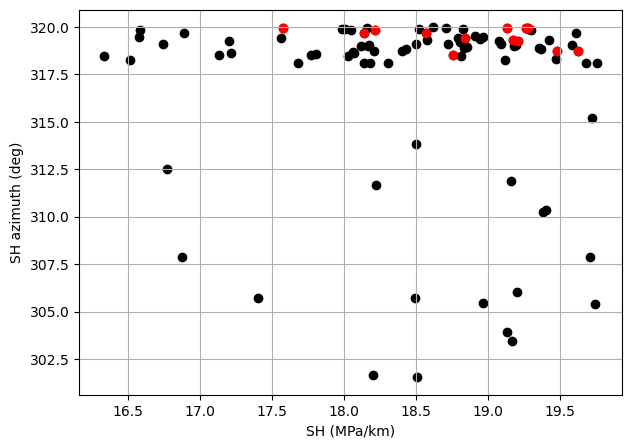

In [133]:
import matplotlib.pyplot as plt

parameters = pd.read_csv(base_path/'data'/'params_responses'/f'{name_prefix}_CMG_parameters.csv')
# plt.figure(1) creates a new, separate window.
plt.figure(1, figsize=(7, 5))
plt.scatter(parameters['SH_MPa/km']*(-1), parameters['SH_azi_deg'],color='black')
plt.scatter(parameters['SH_MPa/km'].iloc[np.nonzero(arr[:,0,2])]*(-1), parameters['SH_azi_deg'].iloc[np.nonzero(arr[:,0,2])],color='red')
# plt.scatter(high_ratio['Vert_Base_Are'], high_ratio['SH_azi_deg'],color='red',label='high stress ratio')
plt.xlabel('SH (MPa/km)')
plt.ylabel('SH azimuth (deg)')
plt.grid(True)
# plt.legend(loc='lower right')

In [12]:
name_prefix = '251208'
arr = np.load(fault_slip_analysis_folder/f'{name_prefix}_total_failed_cells.npy')
print(arr.shape)
print(np.nonzero(arr[:,0,2]))
print(arr[:,0,2])
parameters = pd.read_csv(base_path/'data'/'params_responses'/f'{name_prefix}_CMG_parameters.csv')
# print(parameters['SH_MPa/km'].iloc[np.nonzero(arr[:,0,2])]*(-1))
# print(parameters['SH_azi_deg'].iloc[np.nonzero(arr[:,0,2])])

(93, 12, 6)
(array([17, 18, 20, 25, 26, 32, 38, 40, 46, 57, 60, 62, 67, 70, 72, 75, 83,
       85, 87, 88]),)
[  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
   0.   0.   0.  22. 601.   0. 403.   0.   0.   0.   0. 463. 601.   0.
   0.   0.   0.   0. 142.   0.   0.   0.   0.   0.   1.   0.  38.   0.
   0.   0.   0.   0. 601.   0.   0.   0.   0.   0.   0.   0.   0.   0.
   0. 552.   0.   0.   4.   0. 598.   0.   0.   0.   0.  88.   0.   0.
 591.   0. 589.   0.   0. 589.   0.   0.   0.   0.   0.   0.   0. 598.
   0. 598.   0. 559. 599.   0.   0.   0.   0.]


## combine all cases in a numpy array (n_cases,n_faults,n_times) containing total number of slipped cells

In [ ]:
import numpy as np
from pathlib import Path
from tqdm import tqdm

################## User Inputs ############################## 
# name_prefix = '250922'; n_cases = 90; n_faults = 12; n_times = 6
# fault_info = pd.read_csv('data/raw/fault_strike_dip.csv')
# coor_fault = np.load('data/coor_fault/JD_Sula_2025_gmc_coor&fault_reservoir.npy')
fault_info = pd.read_csv(base_path/'data'/'raw'/'fault_strike_dip.csv')
coor_fault = np.load(base_path/'data'/'coor_fault'/'JD_Sula_2025_gmc_coor&fault_reservoir.npy')
# create save folders
FSA_folder = fault_slip_analysis_folder/f'{name_prefix}_FSA'
################## End of User Inputs #######################

FSA_combined = np.full((n_cases,n_faults,n_times), np.nan)

# set up paths
# base_path = Path('.')
# FSA_folder = base_path/'data'/f'{name_prefix}_FSA'

for case_num in tqdm(range(1,n_cases+1), desc='Combining FSA results for all cases'):
    FSA = np.load(FSA_folder/f'case{case_num}_FSA.npy')

    for fault_id in range(0,n_faults):
        # save analysis to the specific fault 
        fault_id_mask = (coor_fault[:,:,:,3] == fault_id)
        FSA_combined[case_num-1,fault_id,:] = np.nansum(FSA[fault_id_mask],axis=0)

# save
np.save(fault_slip_analysis_folder/f'{name_prefix}_FSA_combined.npy',FSA_combined)

print("\nFinished combining FSA results for all cases to one numpy array.")
# np.savetxt(base_path/'data'/f'{save_file_prefix}_FSA_combined.csv',FSA_combined,delimiter=",",fmt="%.4f")

In [42]:
print(FSA_combined.shape)
print(FSA_combined[4,:,:])

(90, 12, 6)
[[0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]]


# estimated Mw exceedance proability

for fault0 only, following two steps:
1. evaluate if a fault would slip
2. if yes, then estimate estimated Mw exceedance proability

In [13]:
import numpy as np
from pathlib import Path
from scipy.stats import gaussian_kde

################## User Inputs ############################## 
# name_prefix = '251104'; n_cases = 86; n_faults = 12; n_times = 6; 
fault_id = 0
slip_threshold = 0.004 # for fault0 0.005 corresponds to at least 6 cells
n_samples = 100_000 # for Monte Carlo sampling
# fault_area = 16_985_344.51 # fault total area in m2, for fault0
Mw_target = 1.5 # target magnitude for exceedance probability
# set up path
# base_path = Path('.')
# count total number of fault cells using the whole grid (not just in the reservior)
# coor_fault = np.load('data/coor_fault/JD_Sula_2025_gmc_coor&fault_reservoir.npy')
coor_fault_all = np.load(base_path/'data/coor_fault/JD_Sula_2025_gmc_coor&fault.npy')
total_failed_cells = np.load(fault_slip_analysis_folder/f'{name_prefix}_total_failed_cells.npy')
parameters = pd.read_csv(base_path/'data'/'params_responses'/f'{name_prefix}_CMG_parameters.csv')
################## End of User Inputs #######################

# fault_cell_count = np.full((n_faults), np.nan)
fault_cell_count_all = np.full((n_faults), np.nan)
for fault_id_itr in range(0,n_faults):
    fault_id_mask_all = (coor_fault_all[:,:,:,3] == fault_id_itr)
    fault_cell_count_all[fault_id_itr] = np.count_nonzero(fault_id_mask_all)

failed_cell_ratio = total_failed_cells / fault_cell_count_all[np.newaxis,:,np.newaxis]

# estimate Mw through Monte Carlo sampling
# initialize an array to hold Mw exceedance probability for all cases and time steps
# Mw_exceedance = np.full((n_cases,n_times), np.nan) # array shape (n_cases,n_times)
Mw_exceedance = np.zeros((n_cases,n_times)) # array shape (n_cases,n_times)

mean_tau = np.load(fault_slip_analysis_folder/f'{name_prefix}_mean_tau.npy')

# run analysis
for case_num in tqdm(range(1,n_cases+1), desc='Estimating moment magnitude'):
    # extract the fault area from the parameter dataframe
    fault_area = parameters.loc[parameters["case_name"] == f'case{case_num}','A_m2'].iloc[0]

    for time_step in range(n_times):
        failure_ratio = failed_cell_ratio[case_num-1,fault_id,time_step]
        if failure_ratio >= slip_threshold:

            mean_shear_stress = mean_tau[case_num-1,fault_id,time_step]
            stress_drop = np.random.uniform(mean_shear_stress * 0.1, mean_shear_stress * 0.9, n_samples)
            rupture_area = np.random.uniform(fault_area * failure_ratio, fault_area, n_samples)
            # calculate moment magnitude
            Mw = (np.log10(stress_drop * rupture_area ** 1.5) - 9.1) * 2 / 3

            # Kernel density for smooth PDF estimate
            kde = gaussian_kde(Mw)
            Mw_grid = np.linspace(Mw.min(), Mw.max(), 1000)
            pdf = kde(Mw_grid)

            # Empirical CDF
            Mw_sorted = np.sort(Mw)
            cdf = np.arange(1, len(Mw_sorted) + 1) / len(Mw_sorted)

            # Exceedance probability = 1 - CDF
            exceedance_prob = 1 - cdf

            # Find exceedance probability at target Mw
            Mw_exceedance[case_num-1,time_step] = np.mean(Mw > Mw_target)

# create headers
# Define column names in a list
column_headers = [f'time{i}' for i in range(n_times)]
# Join the list of names into a single string using your delimiter
header_string = ','.join(column_headers)
np.savetxt(fault_slip_analysis_folder/f'{name_prefix}_Mw_exceedance{Mw_target}_fault0.csv',Mw_exceedance,delimiter=',',fmt='%.4f',header=header_string,comments='')

# print(Mw_exceedance)

Estimating moment magnitude: 100%|██████████| 93/93 [00:31<00:00,  2.95it/s]


In [14]:
Mw_exceedance
print(np.nonzero(Mw_exceedance[:,2]))
print(np.count_nonzero(Mw_exceedance[:,2]))
Mw_exceedance[:,2]
# np.mean(Mw_exceedance[:,2])

(array([17, 18, 20, 25, 26, 32, 40, 46, 57, 62, 67, 70, 72, 75, 83, 85, 87,
       88]),)
18


array([0.     , 0.     , 0.     , 0.     , 0.     , 0.     , 0.     ,
       0.     , 0.     , 0.     , 0.     , 0.     , 0.     , 0.     ,
       0.     , 0.     , 0.     , 0.2414 , 0.50831, 0.     , 0.37784,
       0.     , 0.     , 0.     , 0.     , 0.36736, 0.50896, 0.     ,
       0.     , 0.     , 0.     , 0.     , 0.26962, 0.     , 0.     ,
       0.     , 0.     , 0.     , 0.     , 0.     , 0.21335, 0.     ,
       0.     , 0.     , 0.     , 0.     , 0.53321, 0.     , 0.     ,
       0.     , 0.     , 0.     , 0.     , 0.     , 0.     , 0.     ,
       0.     , 0.41404, 0.     , 0.     , 0.     , 0.     , 0.55803,
       0.     , 0.     , 0.     , 0.     , 0.26418, 0.     , 0.     ,
       0.58314, 0.     , 0.41158, 0.     , 0.     , 0.52142, 0.     ,
       0.     , 0.     , 0.     , 0.     , 0.     , 0.     , 0.56218,
       0.     , 0.44224, 0.     , 0.49464, 0.41865, 0.     , 0.     ,
       0.     , 0.     ])

In [118]:
parameters = pd.read_csv(base_path/'data'/'params_responses'/f'{name_prefix}_CMG_parameters.csv')
parameters['SH_azi_deg'].iloc[np.nonzero(Mw_exceedance[:,2])]

17    319.8449
25    319.9424
27    319.6814
30    318.7329
53    319.9319
68    318.4956
82    319.8959
88    319.6633
Name: SH_azi_deg, dtype: float64

## plot importance samples

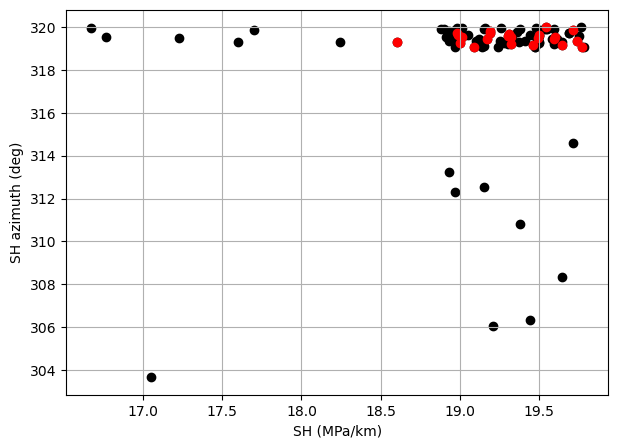

In [163]:
import matplotlib.pyplot as plt

parameters = pd.read_csv(base_path/'data'/'params_responses'/f'{name_prefix}_CMG_parameters.csv')
# plt.figure(1) creates a new, separate window.
plt.figure(1, figsize=(7, 5))
plt.scatter(parameters['SH_MPa/km']*(-1), parameters['SH_azi_deg'],color='black')
plt.scatter(parameters['SH_MPa/km'].iloc[np.nonzero(Mw_exceedance[:,2])]*(-1), parameters['SH_azi_deg'].iloc[np.nonzero(Mw_exceedance[:,2])],color='red')
# plt.scatter(high_ratio['Vert_Base_Are'], high_ratio['SH_azi_deg'],color='red',label='high stress ratio')
plt.xlabel('SH (MPa/km)')
plt.ylabel('SH azimuth (deg)')
plt.grid(True)
# plt.legend(loc='lower right')

Exceedance probability P(Mw > 1.8) = 0.0032


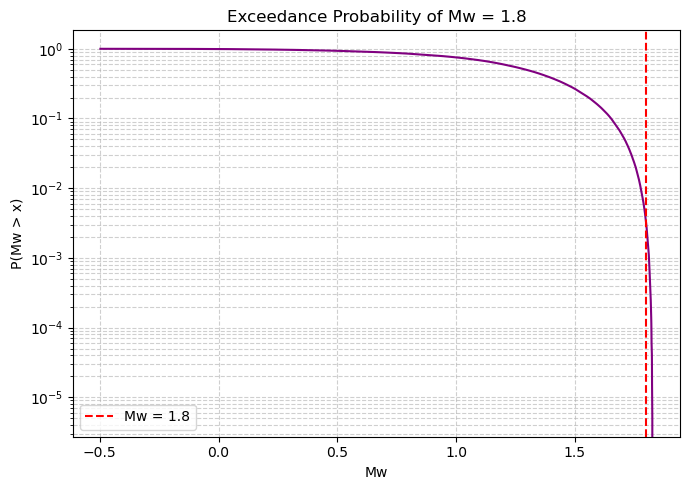

In [56]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# Simulation parameters
n_samples = 200_000
tau_drop = 11
fault_area = 16_985_344.51

# Random samples
a = np.random.uniform(tau_drop * 0.1, tau_drop * 0.9, n_samples)
b = np.random.uniform(fault_area * 0.02, fault_area, n_samples)

# Define transformation
Mw = (np.log10(a * b ** 1.5) - 9.1) * 2 / 3

# Kernel density for smooth PDF estimate
kde = gaussian_kde(Mw)
Mw_grid = np.linspace(Mw.min(), Mw.max(), 1000)
pdf = kde(Mw_grid)

# Empirical CDF
Mw_sorted = np.sort(Mw)
cdf = np.arange(1, len(Mw_sorted) + 1) / len(Mw_sorted)

# Exceedance probability = 1 - CDF
exceedance_prob = 1 - cdf

# Find exceedance probability for Mw = 2
Mw_target = 1.8
prob_exceed_Mw2 = np.mean(Mw > Mw_target)
print(f"Exceedance probability P(Mw > {Mw_target}) = {prob_exceed_Mw2:.4f}")

# Plot exceedance probability
plt.figure(figsize=(7, 5))
plt.plot(Mw_sorted, exceedance_prob, color='purple')
plt.title('Exceedance Probability of Mw = 1.8')
plt.xlabel('Mw')
plt.ylabel('P(Mw > x)')
plt.yscale('log')  # Often exceedance probability is shown on a log scale
plt.grid(True, which="both", linestyle="--", alpha=0.6)

# Mark Mw=2
plt.axvline(Mw_target, color='red', linestyle='--', label=f'Mw = {Mw_target}')
plt.legend()

plt.tight_layout()
plt.show()


## calculate the (number of cases with fault slip / total cases)

In [50]:
import numpy as np
from pathlib import Path

name_prefix = '250922'
base_path = Path('.')

FSA_combined = np.load(base_path/'data'/f'{name_prefix}_FSA_combined.npy')
no_slip_count = np.sum(FSA_combined == 0, axis=0)
slip_probability = 1 - no_slip_count/FSA_combined.shape[0]
# np.savetxt(base_path/'data'/f'{save_file_prefix}_FSA_probability.csv',slip_probability,delimiter=",",fmt="%.4f")
# Save as CSV
df = pd.DataFrame(
    slip_probability,
    columns=[f"time_{t}" for t in range(n_times)]
)
df.insert(0, "fault_id", range(n_faults))

df.to_csv(base_path/'data'/f'{name_prefix}_FSA_probability.csv', index=False, float_format="%.4f")
df

,fault_id,time_0,time_1,time_2,time_3,time_4,time_5
0,0,0.0,0.0,0.022222,0.033333,0.033333,0.022222
1,1,0.0,0.0,0.000000,0.000000,0.000000,0.000000
2,2,0.0,0.0,0.000000,0.000000,0.000000,0.000000
3,3,0.0,0.0,0.000000,0.000000,0.000000,0.000000
4,4,0.0,0.0,0.033333,0.011111,0.011111,0.011111
5,5,0.0,0.0,0.000000,0.000000,0.000000,0.000000
6,6,0.0,0.0,0.033333,0.066667,0.044444,0.044444
7,7,0.0,0.0,0.000000,0.000000,0.000000,0.000000
8,8,0.0,0.0,0.000000,0.000000,0.000000,0.000000
9,9,0.0,0.0,0.000000,0.000000,0.000000,0.000000


# calculate responses for DGSA sensitivity analysis

stress ratio and Mw exceedance probability for fault0

In [174]:
import numpy as np
from pathlib import Path

Mw_target = 1.5 # target magnitude for exceedance probability
name_prefix = '251023'; fault_id = [0]; year = 2050; year_list = [2030, 2040, 2050, 2060, 2550, 3050]
base_path = Path('.')
mean_stress_ratio = np.load(base_path/'data'/f'{name_prefix}_mean_stress_ratio.npy')
Mw_exceedance_prob = np.loadtxt(base_path/'data'/f'{name_prefix}_Mw_exceedance{Mw_target}_fault0.csv',delimiter=',',skiprows=1)
resp = mean_stress_ratio[:,fault_id,year_list.index(year)]
resp = np.insert(resp,1,Mw_exceedance_prob[:,year_list.index(year)],axis=1)

np.savetxt(f'data/params_responses/{name_prefix}_CMG_responses_fault{fault_id}.csv',resp,delimiter=',',fmt='%.4f',header=f'stress_ratio,exceedance{Mw_target}_prob',comments='')
print(mean_stress_ratio.shape)
print(Mw_exceedance_prob.shape)
resp

(90, 12, 6)
(90, 6)


array([[0.56060279, 0.        ],
       [0.55464004, 0.        ],
       [0.55763848, 0.        ],
       [0.55605423, 0.        ],
       [0.58277697, 0.        ],
       [0.61458712, 0.5636    ],
       [0.59395949, 0.2692    ],
       [0.55113539, 0.        ],
       [0.48577605, 0.        ],
       [0.57148702, 0.        ],
       [0.53368451, 0.        ],
       [0.58456919, 0.        ],
       [0.50165047, 0.        ],
       [0.54394929, 0.        ],
       [0.52532833, 0.        ],
       [0.51560108, 0.        ],
       [0.53859826, 0.        ],
       [0.60359795, 0.4531    ],
       [0.55071477, 0.        ],
       [0.52902567, 0.        ],
       [0.52619816, 0.        ],
       [0.53513798, 0.        ],
       [0.55192879, 0.        ],
       [0.59228606, 0.226     ],
       [0.54370425, 0.        ],
       [0.60983362, 0.4328    ],
       [0.48385002, 0.        ],
       [0.58667367, 0.        ],
       [0.60059314, 0.377     ],
       [0.54958008, 0.        ],
       [0.